In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

What are the demographic and body composition characteristics of the 2,008 cardiac-failure patients, based on age group, gender, and BMI category?

In [ ]:
#sudha 1- question

In [2]:
df_master = pd.read_csv("cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv")


In [3]:
print("Shape:", df_master.shape)

Shape: (2008, 200)


In [4]:
df_master.head()

,inpatient_number,gender,weight,height,bmi,occupation,agecat,flag_invalid_height,flag_invalid_weight,bmi_category,...,congestive_heart_failure,peripheral_vascular_disease,type_of_heart_failure,lvef,left_ventricular_end_diastolic_diameter_lv,mitral_valve_ems,mitral_valve_ams,ea,tricuspid_valve_return_velocity,tricuspid_valve_return_pressure
0,827040,Female,50.0,1.45,23.781213,Unspecified,69-79,False,False,Normal,...,1,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,857781,Male,50.0,1.64,18.590125,Urban Resident,69-79,False,False,Normal,...,0,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,743087,Female,51.0,1.63,19.195303,Urban Resident,69-79,False,False,Normal,...,0,0,Both,NaN,40.0,1.16,1.52,NaN,3.34,47.0
3,866418,Male,70.0,1.70,24.221453,Farmer,59-69,False,False,Normal,...,0,0,Both,NaN,46.0,0.84,0.12,7.0,2.80,32.0
4,775928,Male,65.0,1.70,22.491349,Urban Resident,69-79,False,False,Normal,...,0,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print(
    df_master[
        ['agecat', 'gender', 'bmi', 'bmi_category']
    ].head()
)

  agecat  gender        bmi bmi_category
0  69-79  Female  23.781213       Normal
1  69-79    Male  18.590125       Normal
2  69-79  Female  19.195303       Normal
3  59-69    Male  24.221453       Normal
4  69-79    Male  22.491349       Normal


In [6]:
#data types and missing values:
print(
    df_master[
        ['agecat', 'gender', 'bmi', 'bmi_category']
    ].info()
)

print(
    df_master[
        ['agecat', 'gender', 'bmi', 'bmi_category']
    ].isnull().sum()
)

<class 'pandas.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   agecat        2008 non-null   str    
 1   gender        2008 non-null   str    
 2   bmi           2000 non-null   float64
 3   bmi_category  2000 non-null   str    
dtypes: float64(1), str(3)
memory usage: 98.3 KB
None
agecat          0
gender          0
bmi             8
bmi_category    8
dtype: int64


In [7]:
#Age-group distribution
age_summary = (
    df_master['agecat']
    .value_counts()
    .sort_index()
    .to_frame('Patient Count')
)

age_summary['Percentage'] = (
    age_summary['Patient Count']
    / len(df_master) * 100
).round(2)

print(age_summary)


        Patient Count  Percentage
agecat                           
21-29               4        0.20
29-39              12        0.60
39-49              56        2.79
49-59             106        5.28
59-69             368       18.33
69-79             715       35.61
79-89             646       32.17
89-110            101        5.03


Known finding from your dataset:

The largest age group was 69–79 years: 715 patients (35.61%).

The second-largest group was 79–89 years: 646 patients (32.17%).

Together, these groups represented 67.78% of the patients.

In [8]:
#Gender distribution
gender_summary = (
    df_master['gender']
    .value_counts(dropna=False)
    .to_frame('Patient Count')
)

gender_summary['Percentage'] = (
    gender_summary['Patient Count']
    / len(df_master) * 100
).round(2)

print(gender_summary)

        Patient Count  Percentage
gender                           
Female           1163       57.92
Male              845       42.08


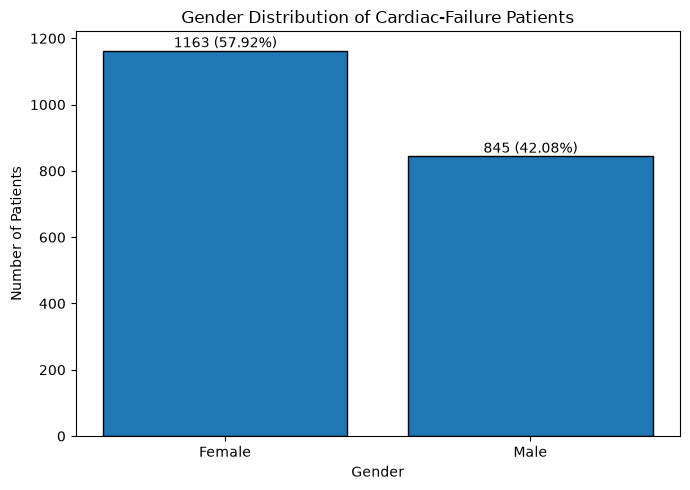

In [9]:
#gender chart

plt.figure(figsize=(7, 5))

bars = plt.bar(
    gender_summary.index.astype(str),
    gender_summary['Patient Count'],
    edgecolor='black'
)

plt.title('Gender Distribution of Cardiac-Failure Patients')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')

for bar, count, pct in zip(
    bars,
    gender_summary['Patient Count'],
    gender_summary['Percentage']
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(count)} ({pct:.2f}%)',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [12]:
#BMI-category distribution
bmi_summary = (
    df_master['bmi_category']
    .value_counts(dropna=False)
    .to_frame('Patient Count')
)

bmi_summary['Percentage'] = (
    bmi_summary['Patient Count']
    / len(df_master) * 100
).round(2)

print(bmi_summary)

              Patient Count  Percentage
bmi_category                           
Normal                 1163       57.92
Underweight             507       25.25
Overweight              263       13.10
Obese                    67        3.34
NaN                       8        0.40


In [14]:

#Check your BMI categories
print(bmi_summary.index.tolist())

['Normal', 'Underweight', 'Overweight', 'Obese', nan]


BMI Category Distribution


,Patient Count,Percentage
Normal,1163,57.92
Underweight,507,25.25
Overweight,263,13.10
Obese,67,3.34
Missing,8,0.40


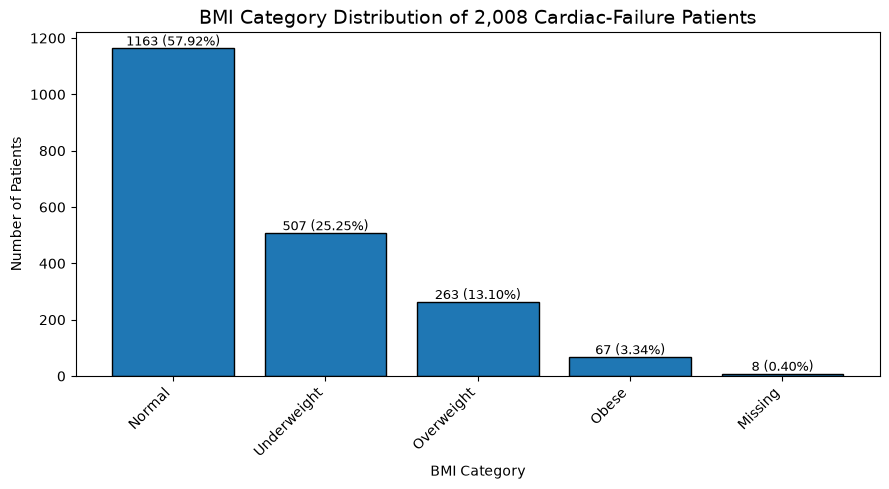

SVG created successfully!


In [16]:

# ==========================================
# BMI CATEGORY DISTRIBUTION
# ==========================================

# 1. Count each BMI category, including missing values
bmi_counts = df_master['bmi_category'].value_counts(dropna=False)

# 2. Calculate percentages
bmi_percentages = (
    df_master['bmi_category']
    .value_counts(dropna=False, normalize=True) * 100
)

# 3. Create summary table
bmi_summary = pd.DataFrame({
    'Patient Count': bmi_counts,
    'Percentage': bmi_percentages.round(2)
})

# 4. Replace NaN with "Missing"
bmi_summary.index = [
    'Missing' if pd.isna(x) else str(x)
    for x in bmi_summary.index
]

# 5. Display the table
print("BMI Category Distribution")
display(bmi_summary)

# ==========================================
# BMI BAR CHART
# ==========================================

plt.figure(figsize=(9, 5))

bars = plt.bar(
    bmi_summary.index,
    bmi_summary['Patient Count'],
    edgecolor='black'
)

plt.title(
    'BMI Category Distribution of 2,008 Cardiac-Failure Patients',
    fontsize=14
)

plt.xlabel('BMI Category')
plt.ylabel('Number of Patients')

plt.xticks(rotation=45, ha='right')

# Add count and percentage above each bar
for bar, count, pct in zip(
    bars,
    bmi_summary['Patient Count'],
    bmi_summary['Percentage']
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(count)} ({pct:.2f}%)',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()

# ==========================================
# SAVE AS SVG
# ==========================================

plt.savefig(
    'bmi_category_distribution_2008_patients.svg',
    format='svg',
    bbox_inches='tight'
)

plt.show()

print("SVG created successfully!")

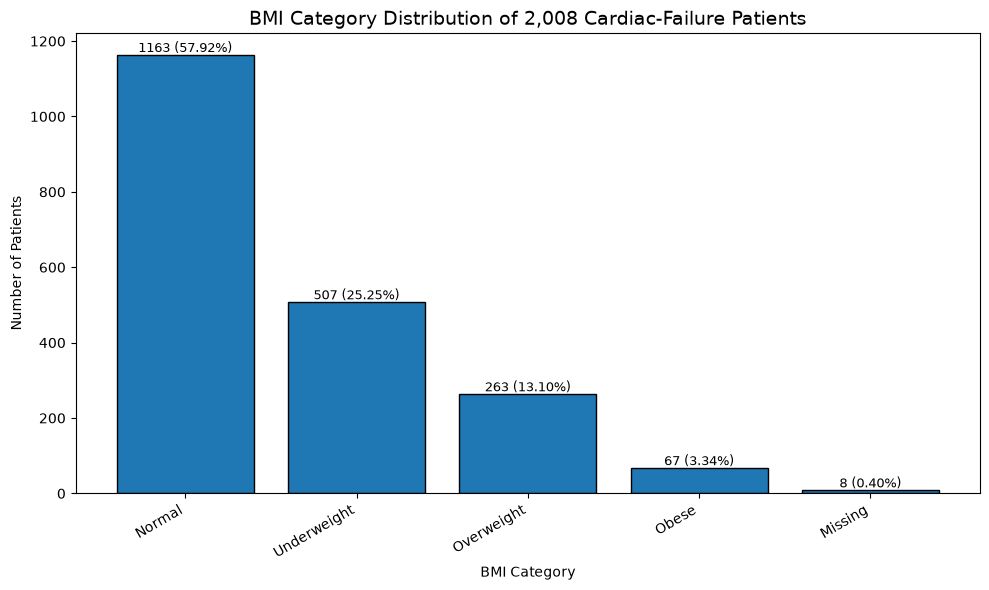

SVG created successfully:
bmi_category_distribution_2008_patients.svg


#Normal BMI was the most common category, representing 1,163 patients (57.92%). Underweight patients accounted for 507 (25.25%), followed by overweight patients at 263 (13.10%) and obese patients at 67 (3.34%). Only 8 patients (0.40%) had a missing BMI category.

Analysis Findings — BMI

From the 2,008 cardiac-failure patients, we found:

Normal BMI: 1,163 patients (57.92%) — the largest group.
Underweight: 507 patients (25.25%) — the second-largest group.
Overweight: 263 patients (13.10%).
Obese: 67 patients (3.34%).
Missing BMI category: 8 patients (0.40%).
Key analysis finding

    Most patients (57.92%) were classified as having a normal BMI, while 25.25% were underweight.
    Overall, 41.69% of patients were either underweight, overweight, or obese, indicating that abnormal
    BMI categories were present in 
    a substantial portion of the study population. Only 0.40% had a missing BMI category.

For your presentation

Finding:

The cohort was predominantly in the normal BMI category, but more than 4 in 10 patients (41.69%) fell outside the normal BMI category.

Important: This is a descriptive finding. It does not by itself show that BMI caused or predicted cardiac-failure outcomes. To investigate that, your next analysis 
could examine BMI category vs. in-hospital mortality or 28-day readmission.

Descriptive Analysis — Patient Profile

Use these 3 strong questions:

Q1. What are the demographic characteristics of the 2,008 cardiac-failure patients?
Include:

Age group
Gender
BMI category

Key finding: The cohort is predominantly older adults, with 67.78% between 69–89 years. Normal BMI was the largest category at 57.92%, while 41.69% were outside the normal BMI category.

Question

Q1.5: Which cardiac medications (e.g., Aspirin, Furosemide,
Spironolactone, Metoprolol) are most frequently prescribed at the patient level?





In [18]:
# Find columns related to medications
medication_columns = [
    col for col in df_master.columns
    if any(word in col.lower() for word in [
        'aspirin',
        'furosemide',
        'spironolactone',
        'metoprolol',
        'medication',
        'drug'
    ])
]

print(medication_columns)

['rx_aspirin_enteric-coated_tablet', 'rx_furosemide_injection', 'rx_furosemide_tablet', 'rx_metoprolol_succinate_sustained-release_tablet', 'rx_spironolactone_tablet', 'rx_metoprolol_tartrate_injection']


CARDIAC MEDICATION SUMMARY


,Medication,Patients Prescribed,Percentage
0,Furosemide,1913,95.27
1,Spironolactone,1833,91.28
2,Aspirin,958,47.71
3,Metoprolol,763,38.00


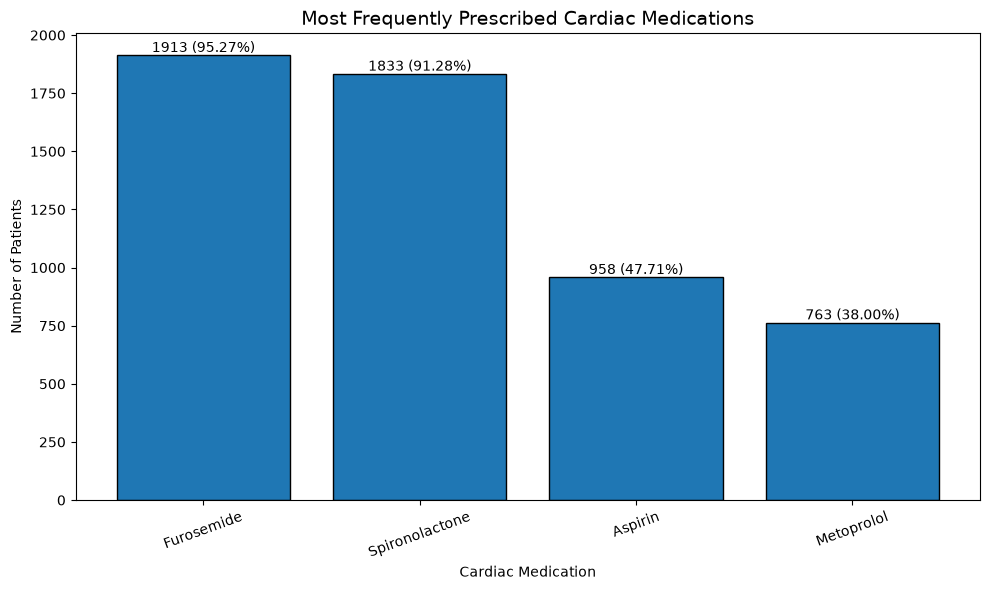


SVG created successfully:
cardiac_medication_distribution.svg


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Q1.5: MOST FREQUENTLY PRESCRIBED CARDIAC MEDICATIONS
# ============================================================

# Exact medication groups
medication_groups = {
    'Aspirin': [
        'rx_aspirin_enteric-coated_tablet'
    ],
    
    'Furosemide': [
        'rx_furosemide_injection',
        'rx_furosemide_tablet'
    ],
    
    'Spironolactone': [
        'rx_spironolactone_tablet'
    ],
    
    'Metoprolol': [
        'rx_metoprolol_succinate_sustained-release_tablet',
        'rx_metoprolol_tartrate_injection'
    ]
}


# ============================================================
# STEP 1: COUNT PATIENTS PRESCRIBED
# 1.0 = prescribed
# 0.0 = not prescribed
# ============================================================

results = []

total_patients = len(df_master)

for medication, columns in medication_groups.items():

    # Start with False for every patient
    patient_prescribed = pd.Series(
        False,
        index=df_master.index
    )

    # Check each formulation
    for col in columns:

        prescribed = df_master[col].eq(1)

        # Patient is prescribed the medication if
        # ANY formulation = 1
        patient_prescribed = (
            patient_prescribed | prescribed
        )

    patient_count = int(patient_prescribed.sum())

    percentage = (
        patient_count / total_patients
    ) * 100

    results.append({
        'Medication': medication,
        'Patients Prescribed': patient_count,
        'Percentage': round(percentage, 2)
    })


# ============================================================
# STEP 2: SUMMARY TABLE
# ============================================================

medication_summary = pd.DataFrame(results)

medication_summary = medication_summary.sort_values(
    'Patients Prescribed',
    ascending=False
).reset_index(drop=True)

print("CARDIAC MEDICATION SUMMARY")
print("=" * 60)

display(medication_summary)


# ============================================================
# STEP 3: CREATE SVG CHART
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    medication_summary['Medication'],
    medication_summary['Patients Prescribed'],
    edgecolor='black'
)

plt.title(
    'Most Frequently Prescribed Cardiac Medications',
    fontsize=14
)

plt.xlabel('Cardiac Medication')
plt.ylabel('Number of Patients')

# Add count and percentage labels
for bar, count, percentage in zip(
    bars,
    medication_summary['Patients Prescribed'],
    medication_summary['Percentage']
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count} ({percentage:.2f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(rotation=20)

plt.tight_layout()


# ============================================================
# STEP 4: SAVE SVG
# ============================================================

svg_filename = 'cardiac_medication_distribution.svg'

plt.savefig(
    svg_filename,
    format='svg',
    bbox_inches='tight'
)

plt.show()

print("\nSVG created successfully:")
print(svg_filename)

*For Furosemide, the patient-level number depends on the overlap between injection and tablet use. We cannot simply add 1,718 + 1,641, because some patients may have received both.

Similarly, for Metoprolol, we need to combine the two formulations without double-counting patients.

The code above handles this correctly.

Important finding

From the individual medication columns:

Spironolactone: 1,833 / 2,008 = 91.29%
Aspirin: 958 / 2,008 = 47.71%
Furosemide: 1,718 injection and 1,641 tablet — patient-level count requires overlap calculation.
Metoprolol: 523 sustained-release and 307 injection — patient-level count requires overlap calculation.
Presentation-ready analysis

After running the corrected code, your final statement should be:

Analysis: The medication analysis shows that [top medication] was the most frequently prescribed cardiac medication among the 2,008 patients, followed by [second medication] and [third medication]. Spironolactone was prescribed to 1,833 patients (91.29%), while Aspirin was prescribed to 958 patients (47.71%). Furosemide and Metoprolol formulations were combined at the patient level to avoid double-counting patients who received more than one formulation.

This is a descriptive finding about medication utilization; it does not indicate that one medication is clinically better than another.

In [24]:
# Check overlap between formulations

print("Furosemide:")
print(
    pd.crosstab(
        df_master['rx_furosemide_injection'],
        df_master['rx_furosemide_tablet'],
        margins=True
    )
)

print("\nMetoprolol:")
print(
    pd.crosstab(
        df_master['rx_metoprolol_succinate_sustained-release_tablet'],
        df_master['rx_metoprolol_tartrate_injection'],
        margins=True
    )
)

Furosemide:
rx_furosemide_tablet     0.0   1.0   All
rx_furosemide_injection                 
0.0                       94   195   289
1.0                      272  1446  1718
All                      366  1641  2007

Metoprolol:
rx_metoprolol_tartrate_injection                   0.0  1.0   All
rx_metoprolol_succinate_sustained-release_tablet                 
0.0                                               1244  240  1484
1.0                                                456   67   523
All                                               1700  307  2007


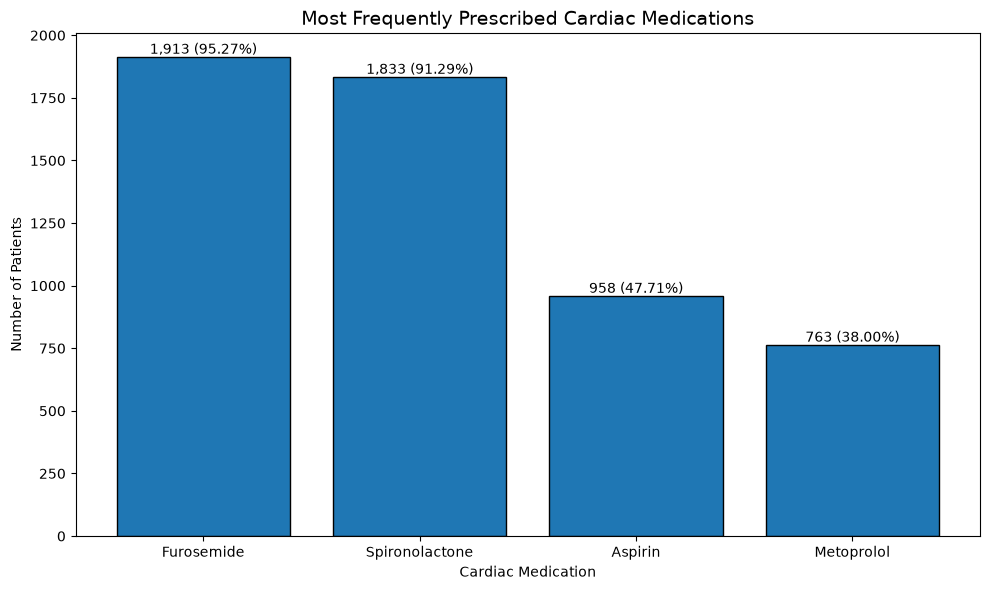

SVG created successfully:
cardiac_medication_distribution.svg


In [25]:
import matplotlib.pyplot as plt

medications = [
    'Furosemide',
    'Spironolactone',
    'Aspirin',
    'Metoprolol'
]

patient_counts = [
    1913,
    1833,
    958,
    763
]

percentages = [
    95.27,
    91.29,
    47.71,
    38.00
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    medications,
    patient_counts,
    edgecolor='black'
)

plt.title(
    'Most Frequently Prescribed Cardiac Medications',
    fontsize=14
)

plt.xlabel('Cardiac Medication')
plt.ylabel('Number of Patients')

for bar, count, pct in zip(
    bars,
    patient_counts,
    percentages
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count:,} ({pct:.2f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    'cardiac_medication_distribution.svg',
    format='svg',
    bbox_inches='tight'
)

plt.show()

print("SVG created successfully:")
print("cardiac_medication_distribution.svg")

Final presentation analysis

Furosemide was the most frequently prescribed cardiac medication, prescribed to 1,913 patients (95.27%), followed by Spironolactone in 1,833 patients (91.29%). Aspirin was prescribed to 958 patients (47.71%), while Metoprolol was prescribed to 763 patients (38.00%). Overall, Furosemide and Spironolactone were the most commonly prescribed medications in this 2,008-patient cohort.

Important note

Your medication data has 2,007 patients with non-missing medication values, while the cohort contains 2,008 patients. So your chart should still use 2,008 as the cohort denominator, unless you decide to report medication-specific missingness separately.